In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

In [2]:
t_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

v_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

device = torch.device("mps" if torch.mps.is_available() else "cpu")


training_set = DataLoader(t_dataset, batch_size=64, shuffle=True)
validation_set = DataLoader(v_dataset, batch_size=128)


In [3]:
class Classifier(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 8, (5, 5)), # (8, 24, 24)
            nn.ReLU(),
            nn.MaxPool2d(2),         # (8, 12, 12)
            nn.Conv2d(8, 8, (3, 3)), # (8, 10, 10)
            nn.ReLU(),
            nn.MaxPool2d(2),         # (8, 5, 5)
            nn.Flatten(),
            nn.Linear(5 * 5 * 8, 10)
        )
        
        
    def forward(self, x):
        return self.model(x)

In [4]:
num_iter = 10
learning_rate = 1e-3
 
train_loss = []
train_accuracy = []
validation_loss = []
validation_accuracy = []
 
model = Classifier().to(device)

loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [5]:
def iter_epoch(model, dataloader, loss_func, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    
    epoch_loss = 0
    correct_classified = 0
    total_examples = 0
    with torch.set_grad_enabled(train):
        for xb, yb in dataloader:
            x = xb.to(device)
            y = yb.to(device)
        
            logits = model(x)
            loss = loss_func(logits, y)
        
            correct_classified += (y == torch.argmax(logits, dim=1)).sum().item()
        
            if train:
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
            
            epoch_loss += loss.item()
            total_examples += x.shape[0]
                 
    return (epoch_loss / len(dataloader)), (correct_classified / total_examples)
    

In [6]:
for epoch in range(1, num_iter + 1):
    
    tr_loss, tr_accuracy = iter_epoch(model, training_set, loss_func, optimizer)
    
    val_loss, val_accuracy = iter_epoch(model, validation_set, loss_func)
    
    train_loss.append(tr_loss)
    train_accuracy.append(tr_accuracy)
    validation_loss.append(val_loss)
    validation_accuracy.append(val_accuracy)
    
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={tr_loss:.4f} train_acc={tr_accuracy:.3f} | "
        f"val_loss={val_loss:.4f} val_acc={val_accuracy:.3f}"
    )

Epoch 01 | train_loss=0.3968 train_acc=0.884 | val_loss=0.1413 val_acc=0.958
Epoch 02 | train_loss=0.1301 train_acc=0.962 | val_loss=0.0979 val_acc=0.969
Epoch 03 | train_loss=0.0997 train_acc=0.970 | val_loss=0.0799 val_acc=0.974
Epoch 04 | train_loss=0.0843 train_acc=0.974 | val_loss=0.0685 val_acc=0.979
Epoch 05 | train_loss=0.0742 train_acc=0.977 | val_loss=0.0627 val_acc=0.980
Epoch 06 | train_loss=0.0674 train_acc=0.979 | val_loss=0.0608 val_acc=0.982
Epoch 07 | train_loss=0.0625 train_acc=0.980 | val_loss=0.0540 val_acc=0.982
Epoch 08 | train_loss=0.0583 train_acc=0.982 | val_loss=0.0522 val_acc=0.984


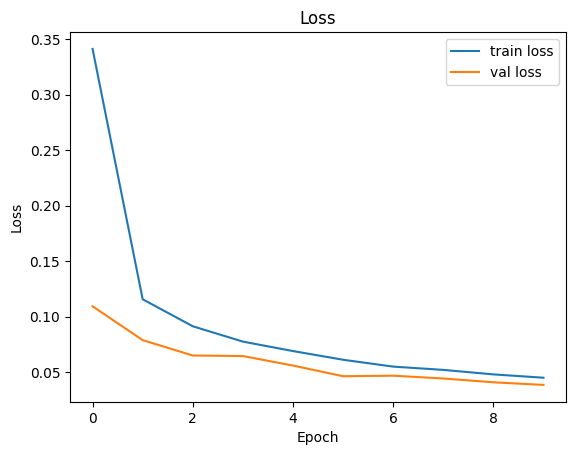

In [ ]:
plt.title("Loss")
plt.plot(train_loss, label="train loss")
plt.plot(validation_loss, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

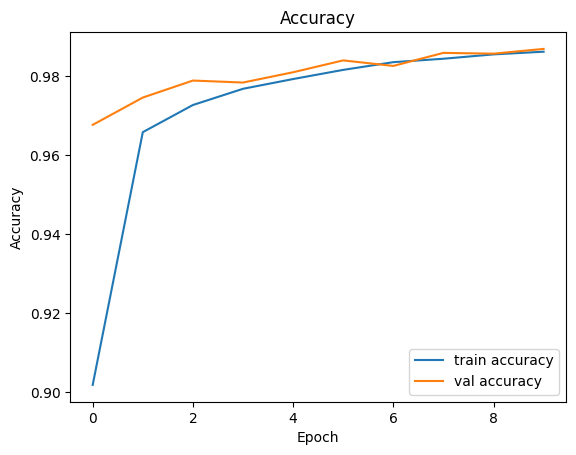

In [ ]:
plt.title("Accuracy")
plt.plot(train_accuracy, label="train accuracy")
plt.plot(validation_accuracy, label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
num_samples = 5
images, labels = next(iter(validation_set))

plt.figure(figsize=(15, 3))
for i in range(num_samples):
    index = torch.randint(len(images), (1,)).item()
    image = images[index].to(device)
    label = labels[index]
    logits = model(image.unsqueeze(0))
    pred = torch.argmax(logits, dim=1)
    
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(images[index].squeeze(), cmap="gray")
    plt.title(f"Label: {label.item()}, Prediction: {pred.item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Save model

In [ ]:
import os

os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/mnist_classifier.pt")

## Load model

Recreate the architecture, then load the saved weights into it.

In [ ]:
loaded_model = Classifier().to(device)
loaded_model.load_state_dict(torch.load("../models/mnist_classifier.pt", map_location=device))
loaded_model.eval()